# 06_Model_Training

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib
import os
import time

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
from xgboost import XGBClassifier

### 2. Load the feature-engineered dataset

In [4]:
data = pd.read_csv(
    'feature_engineered_data.csv'
)

data['HAS_BUREAU_HISTORY'] = (
    data['BUREAU_LOAN_COUNT'].notna()
).astype(int)

data = data.drop(
    columns=['SK_ID_CURR']
)

X = data.drop(columns='TARGET')
y = data['TARGET']

print("X Shape:", X.shape)
print("Target Distribution:")
print(y.value_counts(normalize=True))

X Shape: (50000, 143)
Target Distribution:
TARGET
0    0.91948
1    0.08052
Name: proportion, dtype: float64


### 3. Reproduce the original train/test split

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

In [7]:
print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

print("\nTraining Default Rate:")
print(y_train.mean())

print("\nValidation Default Rate:")
print(y_val.mean())

print("\nTest Default Rate:")
print(y_test.mean())

Training Shape: (32000, 143)
Validation Shape: (8000, 143)
Test Shape: (10000, 143)

Training Default Rate:
0.08053125

Validation Default Rate:
0.0805

Test Default Rate:
0.0805


### 4. Remove high-missingness columns

In [8]:
missing_percentage = (
    X_train_full
    .isnull()
    .mean()
    .mul(100)
)

high_missing_columns = (
    missing_percentage[
        missing_percentage > 60
    ]
    .index
    .tolist()
)

X_train = X_train.drop(
    columns=high_missing_columns
)

X_val = X_val.drop(
    columns=high_missing_columns
)

X_test = X_test.drop(
    columns=high_missing_columns
)

print("High-Missingness Columns:", len(high_missing_columns))

High-Missingness Columns: 17


### 5. Load model-specific feature sets

In [9]:
logistic_num_features = joblib.load(
    'models/final_logistic_numerical_features.joblib'
)

logistic_cat_features = joblib.load(
    'models/final_logistic_categorical_features.joblib'
)

tree_num_features = joblib.load(
    'models/tree_numerical_features.joblib'
)

tree_cat_features = joblib.load(
    'models/tree_categorical_features.joblib'
)

In [11]:
# validate
print(
    "Logistic Numerical:",
    len(logistic_num_features)
)

print(
    "Logistic Categorical:",
    len(logistic_cat_features)
)

print(
    "Tree Numerical:",
    len(tree_num_features)
)

print(
    "Tree Categorical:",
    len(tree_cat_features)
)

Logistic Numerical: 49
Logistic Categorical: 12
Tree Numerical: 93
Tree Categorical: 15


In [12]:
# Also check that all selected features are available:
all_selected_features = (
    logistic_num_features
    + logistic_cat_features
    + tree_num_features
    + tree_cat_features
)

missing_selected_features = [
    feature
    for feature in set(all_selected_features)
    if feature not in X_train.columns
]

print(
    "Missing Selected Features:",
    missing_selected_features
)

Missing Selected Features: []


# Part A: Logistic Regression
### 6. Logistic Regression preprocessing

In [14]:
logistic_numerical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),

        (
            'scaler',
            StandardScaler()
        )
    ]
)

In [15]:
logistic_categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),

        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

In [17]:
# Combined:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            logistic_numerical_pipeline,
            logistic_num_features
        ),

        (
            'cat',
            logistic_categorical_pipeline,
            logistic_cat_features
        )
    ]
)

### 7. Logistic Regression pipeline

In [18]:
logistic_model = Pipeline(
    steps=[
        (
            'preprocessor',
            logistic_preprocessor
        ),

        (
            'classifier',
            LogisticRegression(
                class_weight='balanced',
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

### 8. Train Logistic Regression

In [19]:
start_time = time.time()

logistic_model.fit(
    X_train,
    y_train
)

logistic_training_time = (
    time.time() - start_time
)

print(
    "Logistic Regression Training Time:",
    round(logistic_training_time, 2),
    "seconds"
)

Logistic Regression Training Time: 2.78 seconds


### 9. Validation probabilities

In [22]:
logistic_val_probability = (
    logistic_model.predict_proba(
        X_val
    )[:, 1]
)

# Part B: Random Forest
### 10. Random Forest preprocessing

In [24]:
tree_numerical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        )
    ]
)

In [25]:
tree_categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),

        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

In [26]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            tree_numerical_pipeline,
            tree_num_features
        ),

        (
            'cat',
            tree_categorical_pipeline,
            tree_cat_features
        )
    ]
)

### 11. Random Forest pipeline

In [28]:
random_forest_model = Pipeline(
    steps=[
        (
            'preprocessor',
            tree_preprocessor
        ),

        (
            'classifier',
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=10,
                class_weight='balanced',
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

### 12. Train Random Forest

In [29]:
start_time = time.time()

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_training_time = (
    time.time() - start_time
)

print(
    "Random Forest Training Time:",
    round(random_forest_training_time, 2),
    "seconds"
)

Random Forest Training Time: 11.13 seconds


In [30]:
random_forest_val_probability = (
    random_forest_model.predict_proba(
        X_val
    )[:, 1]
)

# Part C: XGBoost
### 13. Calculate imbalance ratio

In [32]:
negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_count
    / positive_count
)

print(
    "scale_pos_weight:",
    scale_pos_weight
)

scale_pos_weight: 11.417539774932091


### 14. XGBoost pipeline

In [33]:
xgboost_model = Pipeline(
    steps=[
        (
            'preprocessor',
            tree_preprocessor
        ),

        (
            'classifier',
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                eval_metric='logloss',
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

### 15. Train XGBoost

In [34]:
start_time = time.time()

xgboost_model.fit(
    X_train,
    y_train
)

xgboost_training_time = (
    time.time() - start_time
)

print(
    "XGBoost Training Time:",
    round(xgboost_training_time, 2),
    "seconds"
)

XGBoost Training Time: 5.81 seconds


In [35]:
xgboost_val_probability = (
    xgboost_model.predict_proba(
        X_val
    )[:, 1]
)

# Part D: Baseline Model Comparison
### 16. Evaluation function

In [36]:
def evaluate_model(
    model_name,
    y_true,
    probabilities,
    training_time,
    threshold=0.5
):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions
    ).ravel()

    results = {
        'MODEL': model_name,

        'ROC_AUC':
            roc_auc_score(
                y_true,
                probabilities
            ),

        'PR_AUC':
            average_precision_score(
                y_true,
                probabilities
            ),

        'PRECISION':
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        'RECALL':
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        'F1_SCORE':
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        'BALANCED_ACCURACY':
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,

        'TRAINING_TIME_SECONDS':
            training_time
    }

    return results

### 17. Compare models

In [37]:
baseline_results = []

baseline_results.append(
    evaluate_model(
        'Logistic Regression',
        y_val,
        logistic_val_probability,
        logistic_training_time
    )
)

baseline_results.append(
    evaluate_model(
        'Random Forest',
        y_val,
        random_forest_val_probability,
        random_forest_training_time
    )
)

baseline_results.append(
    evaluate_model(
        'XGBoost',
        y_val,
        xgboost_val_probability,
        xgboost_training_time
    )
)

baseline_results = pd.DataFrame(
    baseline_results
)

baseline_results.sort_values(
    'ROC_AUC',
    ascending=False
)

,MODEL,ROC_AUC,PR_AUC,PRECISION,RECALL,F1_SCORE,BALANCED_ACCURACY,TN,FP,FN,TP,TRAINING_TIME_SECONDS
2,XGBoost,0.751337,0.247681,0.185168,0.608696,0.283955,0.687097,5631,1725,252,392,5.814270
0,Logistic Regression,0.748210,0.227542,0.161912,0.678571,0.261442,0.685534,5094,2262,207,437,2.779811
1,Random Forest,0.738376,0.226496,0.237877,0.403727,0.299367,0.645243,6523,833,384,260,11.128398


### 18. ROC curves

<Figure size 800x600 with 0 Axes>

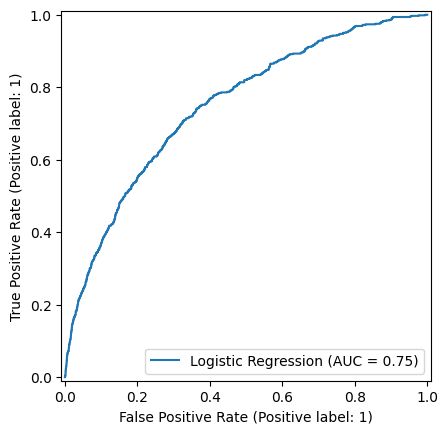

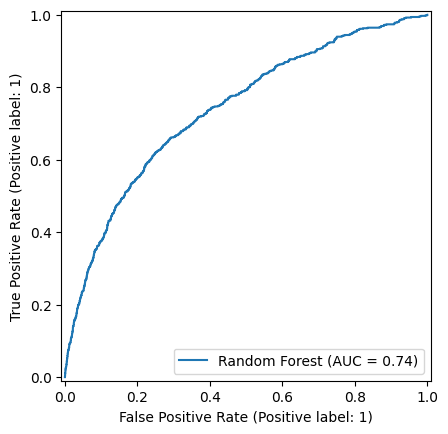

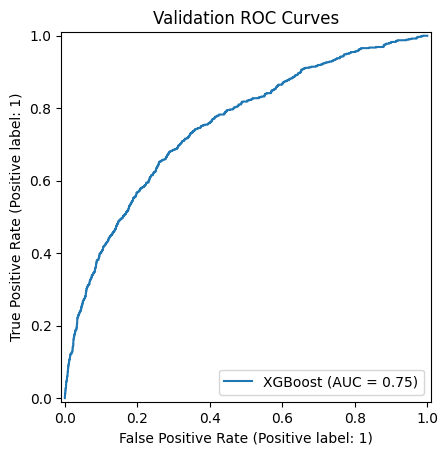

In [38]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_val,
    logistic_val_probability,
    name='Logistic Regression'
)

RocCurveDisplay.from_predictions(
    y_val,
    random_forest_val_probability,
    name='Random Forest'
)

RocCurveDisplay.from_predictions(
    y_val,
    xgboost_val_probability,
    name='XGBoost'
)

plt.title('Validation ROC Curves')
plt.show()

### 19. Precision-Recall curves

<Figure size 800x600 with 0 Axes>

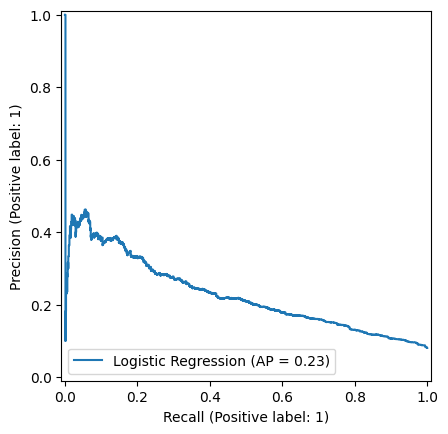

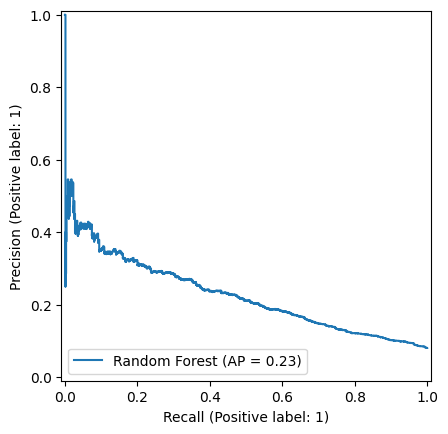

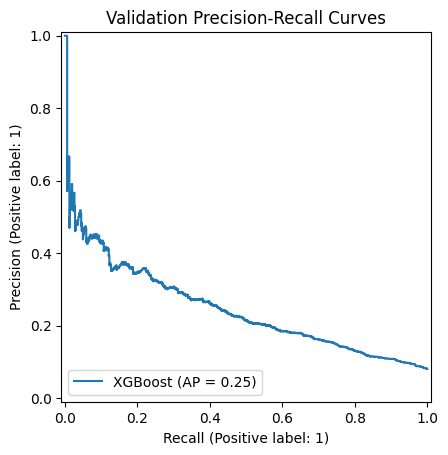

In [39]:
plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_val,
    logistic_val_probability,
    name='Logistic Regression'
)

PrecisionRecallDisplay.from_predictions(
    y_val,
    random_forest_val_probability,
    name='Random Forest'
)

PrecisionRecallDisplay.from_predictions(
    y_val,
    xgboost_val_probability,
    name='XGBoost'
)

plt.title('Validation Precision-Recall Curves')
plt.show()

### 20. Classification reports at threshold 0.5

In [40]:
models_and_probabilities = {
    'Logistic Regression':
        logistic_val_probability,

    'Random Forest':
        random_forest_val_probability,

    'XGBoost':
        xgboost_val_probability
}

for model_name, probabilities in (
    models_and_probabilities.items()
):

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_val,
            predictions,
            digits=3
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0      0.961     0.692     0.805      7356
           1      0.162     0.679     0.261       644

    accuracy                          0.691      8000
   macro avg      0.561     0.686     0.533      8000
weighted avg      0.897     0.691     0.761      8000

Random Forest
              precision    recall  f1-score   support

           0      0.944     0.887     0.915      7356
           1      0.238     0.404     0.299       644

    accuracy                          0.848      8000
   macro avg      0.591     0.645     0.607      8000
weighted avg      0.888     0.848     0.865      8000

XGBoost
              precision    recall  f1-score   support

           0      0.957     0.765     0.851      7356
           1      0.185     0.609     0.284       644

    accuracy                          0.753      8000
   macro avg      0.571     0.687     0.567      8000
weighted avg      0.895     0.75

### 21. Save baseline results and models

In [41]:
os.makedirs(
    'reports',
    exist_ok=True
)

baseline_results.to_csv(
    'reports/baseline_model_results.csv',
    index=False
)

In [42]:
joblib.dump(
    logistic_model,
    'models/baseline_logistic_regression.joblib'
)

joblib.dump(
    random_forest_model,
    'models/baseline_random_forest.joblib'
)

joblib.dump(
    xgboost_model,
    'models/baseline_xgboost.joblib'
)

['models/baseline_xgboost.joblib']

# Baseline Model Training Summary

1. The original test set was kept untouched for final model evaluation.

2. The training data was further divided into training and validation sets using stratified sampling.

3. Separate feature sets and preprocessing pipelines were used for Logistic Regression and tree-based models.

4. Logistic Regression and Random Forest used class-weighting to account for target imbalance, while XGBoost used scale_pos_weight based on the training-class ratio.

5. Models were compared using ROC-AUC and PR-AUC as threshold-independent ranking metrics.

6. Precision, Recall, F1-score, Balanced Accuracy, and confusion-matrix values were calculated at the default threshold of 0.5 for initial comparison.

7. Validation data was used for baseline model comparison, while the test set remained untouched.

8. Threshold optimization and hyperparameter tuning were deferred until after baseline model comparison.

One important point: don't choose the best model based only on F1 at threshold 0.5. Because we used class weighting, the models' probability calibration and default classification behavior can differ considerably. First compare ROC-AUC and PR-AUC, inspect recall/precision trade-offs, and then tune only the models that justify the additional complexity.

### Baseline Model Comparison — Observations

- XGBoost achieved the strongest baseline ranking performance, with the highest ROC-AUC (~ 0.751) and PR-AUC (~ 0.248).

- Logistic Regression achieved a similar ROC-AUC (~ 0.748) but a lower PR-AUC (~ 0.228). At the default threshold of 0.5, it produced the highest recall (~67.9%), identifying the largest proportion of defaulting customers.

- Random Forest achieved the highest precision (~ 23.8%) and F1-score (~ 0.299) at the default threshold but had the lowest ROC-AUC (~ 0.738) and substantially lower recall (~40.4%).

- The differences in threshold-dependent metrics demonstrate that model comparisons should not rely solely on predictions generated using the default threshold of 0.5.

- Accuracy was not used as the primary evaluation metric because the target variable was highly imbalanced, with approximately 92% non-default customers.

- XGBoost was selected as the primary model for hyperparameter tuning because it achieved the strongest ROC-AUC and PR-AUC performance.

- Logistic Regression was retained as an interpretable benchmark because its ranking performance was close to XGBoost and it provides directly interpretable model coefficients.

- Random Forest was not prioritized for extensive hyperparameter tuning because its baseline ranking performance was weaker than the other two models.